In [6]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple
from scipy import stats
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error, r2_score 
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

In [7]:
wine=load_wine()

In [8]:
wine.feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [10]:
wine.data[:5]

array([[1.423e+01, 1.710e+00, 2.430e+00, 1.560e+01, 1.270e+02, 2.800e+00,
        3.060e+00, 2.800e-01, 2.290e+00, 5.640e+00, 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, 1.120e+01, 1.000e+02, 2.650e+00,
        2.760e+00, 2.600e-01, 1.280e+00, 4.380e+00, 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, 1.860e+01, 1.010e+02, 2.800e+00,
        3.240e+00, 3.000e-01, 2.810e+00, 5.680e+00, 1.030e+00, 3.170e+00,
        1.185e+03],
       [1.437e+01, 1.950e+00, 2.500e+00, 1.680e+01, 1.130e+02, 3.850e+00,
        3.490e+00, 2.400e-01, 2.180e+00, 7.800e+00, 8.600e-01, 3.450e+00,
        1.480e+03],
       [1.324e+01, 2.590e+00, 2.870e+00, 2.100e+01, 1.180e+02, 2.800e+00,
        2.690e+00, 3.900e-01, 1.820e+00, 4.320e+00, 1.040e+00, 2.930e+00,
        7.350e+02]])

In [11]:
type(wine.data)

numpy.ndarray

In [12]:
np.unique(wine.target)

array([0, 1, 2])

In [13]:
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [14]:
list(zip(np.unique(wine.target), wine.target_names))

[(np.int64(0), np.str_('class_0')),
 (np.int64(1), np.str_('class_1')),
 (np.int64(2), np.str_('class_2'))]

In [15]:
wine.data.shape, wine.target.shape

((178, 13), (178,))

In [16]:
# Сформируем DataFrame
wine_df = pd.DataFrame(data= np.c_[wine['data'], wine['target']],
                     columns= wine['feature_names'] + ['target'])

In [17]:
# И выведем его статистические характеристики
wine_df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [18]:
wine_X_train, wine_X_test, wine_y_train, wine_y_test = train_test_split(
    wine.data, wine.target, test_size=0.5, random_state=1)

In [19]:
wine_X_train.shape, wine_y_train.shape

((89, 13), (89,))

In [20]:
np.unique(wine_y_train)

array([0, 1, 2])

In [21]:
def class_proportions(array: np.ndarray) -> Dict[int, Tuple[int, float]]:
    # Получение меток классов и количества меток каждого класса 
    labels, counts = np.unique(array, return_counts=True)
    # Превращаем количество меток в процент их встречаемости
    # делим количество меток каждого класса на общее количество меток
    counts_perc = counts/array.size
    # Теперь sum(counts_perc)==1.0
    # Создаем результирующий словарь,
    # ключом словаря явлется метка класса, 
    # а значением словаря процент встречаемости метки
    res = dict()
    for label, count2 in zip(labels, zip(counts, counts_perc)):
        res[label] = count2
    return res

def print_class_proportions(array: np.ndarray):
    proportions = class_proportions(array)
    if len(proportions)>0:
        print('Метка \t Количество \t Процент встречаемости')
    for i in proportions:
        val, val_perc = proportions[i]
        val_perc_100 = round(val_perc * 100, 2)
        print('{} \t {} \t \t {}%'.format(i, val, val_perc_100))

In [22]:
print_class_proportions(wine.target)

Метка 	 Количество 	 Процент встречаемости
0 	 59 	 	 33.15%
1 	 71 	 	 39.89%
2 	 48 	 	 26.97%


In [23]:
# Для обучающей выборки
print_class_proportions(wine_y_train)

Метка 	 Количество 	 Процент встречаемости
0 	 26 	 	 29.21%
1 	 37 	 	 41.57%
2 	 26 	 	 29.21%


In [24]:
# Для тестовой выборки
print_class_proportions(wine_y_test)

Метка 	 Количество 	 Процент встречаемости
0 	 33 	 	 37.08%
1 	 34 	 	 38.2%
2 	 22 	 	 24.72%


In [25]:
# 2 ближайших соседа
cl1_1 = KNeighborsClassifier(n_neighbors=2)
cl1_1.fit(wine_X_train, wine_y_train)
target1_1 = cl1_1.predict(wine_X_test)
len(target1_1), target1_1

(89,
 array([0, 1, 2, 1, 0, 1, 2, 0, 1, 1, 0, 1, 1, 0, 2, 1, 1, 1, 1, 0, 0, 1,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0,
        0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 2, 0,
        1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 2, 2, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0,
        1]))

In [26]:
# 10 ближайших соседей
cl1_2 = KNeighborsClassifier(n_neighbors=10)
cl1_2.fit(wine_X_train, wine_y_train)
target1_2 = cl1_2.predict(wine_X_test)
len(target1_2), target1_2

(89,
 array([1, 1, 2, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1,
        2, 0, 2, 1, 0, 0, 0, 2, 1, 2, 1, 0, 2, 1, 1, 1, 1, 0, 0, 1, 1, 2,
        0, 2, 2, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 2, 2, 1, 0,
        1, 0, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1, 0, 2, 1, 0, 1, 0, 1, 1, 1, 0,
        1]))

In [27]:
# 2 ближайших соседа
accuracy_score(wine_y_test, target1_1)

0.6404494382022472

In [28]:
# 10 ближайших соседей
accuracy_score(wine_y_test, target1_2)

0.6629213483146067

In [29]:
def accuracy_score_for_classes(
    y_true: np.ndarray, 
    y_pred: np.ndarray) -> Dict[int, float]:
    """
    Вычисление метрики accuracy для каждого класса
    y_true - истинные значения классов
    y_pred - предсказанные значения классов
    Возвращает словарь: ключ - метка класса, 
    значение - Accuracy для данного класса
    """
    # Для удобства фильтрации сформируем Pandas DataFrame 
    d = {'t': y_true, 'p': y_pred}
    df = pd.DataFrame(data=d)
    # Метки классов
    classes = np.unique(y_true)
    # Результирующий словарь
    res = dict()
    # Перебор меток классов
    for c in classes:
        # отфильтруем данные, которые соответствуют 
        # текущей метке класса в истинных значениях
        temp_data_flt = df[df['t']==c]
        # расчет accuracy для заданной метки класса
        temp_acc = accuracy_score(
            temp_data_flt['t'].values, 
            temp_data_flt['p'].values)
        # сохранение результата в словарь
        res[c] = temp_acc
    return res

def print_accuracy_score_for_classes(
    y_true: np.ndarray, 
    y_pred: np.ndarray):
    """
    Вывод метрики accuracy для каждого класса
    """
    accs = accuracy_score_for_classes(y_true, y_pred)
    if len(accs)>0:
        print('Метка \t Accuracy')
    for i in accs:
        print('{} \t {}'.format(i, accs[i]))

In [30]:
# 2 ближайших соседа
print_accuracy_score_for_classes(wine_y_test, target1_1)

Метка 	 Accuracy
0 	 0.7878787878787878
1 	 0.8529411764705882
2 	 0.09090909090909091


In [31]:
# 10 ближайших соседей
print_accuracy_score_for_classes(wine_y_test, target1_2)

Метка 	 Accuracy
0 	 0.7878787878787878
1 	 0.8235294117647058
2 	 0.22727272727272727


In [32]:
# Конвертация целевого признака в бинарный
def convert_target_to_binary(array:np.ndarray, target:int) -> np.ndarray:
    # Если целевой признак совпадает с указанным, то 1 иначе 0
    res = [1 if x==target else 0 for x in array]
    return res

In [33]:
# Если целевой признак ==2, 
# то будем считать этот случай 1 в бинарном признаке
bin_wine_y_train = convert_target_to_binary(wine_y_train, 2)
list(zip(wine_y_train, bin_wine_y_train))[:10]

[(np.int64(1), 0),
 (np.int64(1), 0),
 (np.int64(0), 0),
 (np.int64(1), 0),
 (np.int64(1), 0),
 (np.int64(1), 0),
 (np.int64(2), 1),
 (np.int64(1), 0),
 (np.int64(1), 0),
 (np.int64(1), 0)]

In [34]:
bin_wine_y_test = convert_target_to_binary(wine_y_test, 2)
list(zip(wine_y_test, bin_wine_y_test))[:10]

[(np.int64(2), 1),
 (np.int64(1), 0),
 (np.int64(0), 0),
 (np.int64(1), 0),
 (np.int64(0), 0),
 (np.int64(2), 1),
 (np.int64(1), 0),
 (np.int64(0), 0),
 (np.int64(2), 1),
 (np.int64(1), 0)]

In [35]:
# Конвертация предсказанных признаков
bin_target1_1 = convert_target_to_binary(target1_1, 2)
bin_target1_2 = convert_target_to_binary(target1_2, 2)

In [36]:
balanced_accuracy_score(bin_wine_y_test, bin_target1_1)

0.5156037991858887

In [37]:
balanced_accuracy_score(bin_wine_y_test, bin_target1_2)

0.5390094979647219

In [39]:
from sklearn.model_selection import cross_val_score, cross_validate

In [40]:
scores = cross_val_score(KNeighborsClassifier(n_neighbors=2), 
                         wine.data, wine.target, cv=3)

In [41]:
# Значение метрики accuracy для 3 фолдов
scores

array([0.56666667, 0.6440678 , 0.72881356])

In [42]:
# Усредненное значение метрики accuracy для 3 фолдов
np.mean(scores)

np.float64(0.6465160075329566)

In [43]:
# использование метрики f1
# https://scikit-learn.org/stable/modules/model_evaluation.html
scores = cross_val_score(KNeighborsClassifier(n_neighbors=2), 
                         wine.data, wine.target, cv=3,
                        scoring='f1_weighted')
scores, np.mean(scores)

(array([0.51069094, 0.6198816 , 0.6798559 ]), np.float64(0.6034761483135361))

In [44]:
scoring = {'precision': 'precision_weighted', 
           'recall': 'recall_weighted',
           'f1': 'f1_weighted'}

In [45]:
scores = cross_validate(KNeighborsClassifier(n_neighbors=2), 
                        wine.data, wine.target, scoring=scoring, 
                        cv=3, return_train_score=True)
scores

{'fit_time': array([0.00138426, 0.00206518, 0.00126505]),
 'score_time': array([0.01346803, 0.02629185, 0.03534651]),
 'test_precision': array([0.48984127, 0.62317561, 0.70585516]),
 'train_precision': array([0.91000807, 0.8877454 , 0.85825075]),
 'test_recall': array([0.56666667, 0.6440678 , 0.72881356]),
 'train_recall': array([0.89830508, 0.87394958, 0.83193277]),
 'test_f1': array([0.51069094, 0.6198816 , 0.6798559 ]),
 'train_f1': array([0.89415947, 0.8703245 , 0.8181316 ])}

In [46]:
n_range = np.array(range(5,55,5))
tuned_parameters = [{'n_neighbors': n_range}]
tuned_parameters

[{'n_neighbors': array([ 5, 10, 15, 20, 25, 30, 35, 40, 45, 50])}]

In [49]:
from sklearn.model_selection import KFold, RepeatedKFold, LeaveOneOut, LeavePOut, ShuffleSplit, StratifiedKFold

In [50]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [51]:
%%time
clf_gs = GridSearchCV(KNeighborsClassifier(), tuned_parameters, cv=5, scoring='accuracy')
clf_gs.fit(wine_X_train, wine_y_train)

CPU times: total: 1.22 s
Wall time: 4.14 s


,estimator,KNeighborsClassifier()
,param_grid,"[{'n_neighbors': array([ 5, 10..., 40, 45, 50])}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,np.int64(15)


In [52]:
clf_gs.cv_results_

{'mean_fit_time': array([0.00139241, 0.00184994, 0.00195947, 0.00224028, 0.00173049,
        0.0012887 , 0.00104113, 0.00096335, 0.00096059, 0.00113573]),
 'std_fit_time': array([2.59580242e-04, 1.65816610e-04, 4.73194841e-04, 4.64267048e-04,
        3.78884328e-04, 1.48567216e-04, 1.49781861e-04, 4.34193160e-05,
        1.21542041e-05, 2.24375805e-04]),
 'mean_score_time': array([0.00480866, 0.00609112, 0.00499926, 0.00517969, 0.00448012,
        0.00349011, 0.7357655 , 0.01084762, 0.0122191 , 0.01263318]),
 'std_score_time': array([1.87995108e-03, 8.77572588e-04, 4.42022043e-04, 5.89887487e-04,
        8.78627179e-04, 2.16184190e-04, 1.45332942e+00, 4.91525385e-04,
        6.73690306e-04, 7.12259671e-04]),
 'param_n_neighbors': masked_array(data=[5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
              mask=[False, False, False, False, False, False, False, False,
                    False, False],
        fill_value=999999),
 'params': [{'n_neighbors': np.int64(5)},
  {'n_neighbors': np

In [53]:
# Лучшая модель
clf_gs.best_estimator_

,n_neighbors,np.int64(15)
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [54]:
# Лучшее значение метрики
clf_gs.best_score_

np.float64(0.7189542483660132)

In [55]:
# Лучшее значение параметров
clf_gs.best_params_

{'n_neighbors': np.int64(15)}

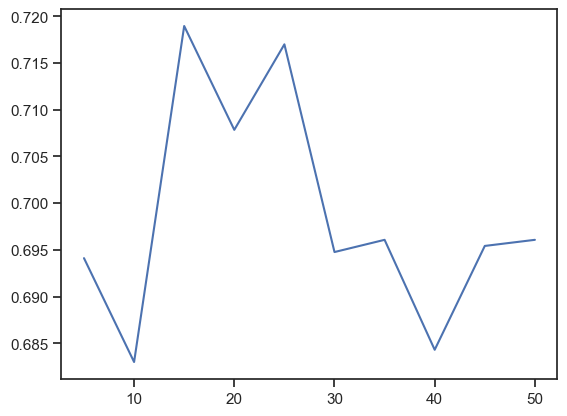

In [56]:
# Изменение качества на тестовой выборке в зависимости от К-соседей
plt.plot(n_range, clf_gs.cv_results_['mean_test_score'])

In [57]:
%%time
clf_rs = RandomizedSearchCV(KNeighborsClassifier(), tuned_parameters, cv=5, scoring='accuracy')
clf_rs.fit(wine_X_train, wine_y_train)

CPU times: total: 984 ms
Wall time: 525 ms


,estimator,KNeighborsClassifier()
,param_distributions,"[{'n_neighbors': array([ 5, 10..., 40, 45, 50])}]"
,n_iter,10
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [58]:
# В данном случае оба способа нашли одинаковое решение
clf_rs.best_score_, clf_rs.best_params_

(np.float64(0.7189542483660132), {'n_neighbors': np.int64(15)})

In [59]:
clf_gs.best_score_, clf_gs.best_params_

(np.float64(0.7189542483660132), {'n_neighbors': np.int64(15)})

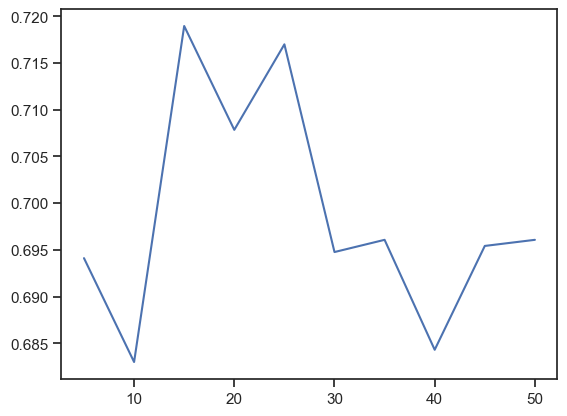

In [60]:
# Изменение качества на тестовой выборке в зависимости от К-соседей
plt.plot(n_range, clf_rs.cv_results_['mean_test_score'])

In [61]:
X = np.ones(10)
y = [0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
skf = StratifiedKFold(n_splits=3)
for train, test in skf.split(X, y):
    print("%s %s" % (train, test))

[1 2 6 7 8 9] [0 3 4 5]
[0 2 3 4 5 8 9] [1 6 7]
[0 1 3 4 5 6 7] [2 8 9]


In [63]:
X = np.ones(10)
y = [0, 0, 0, 0, 1, 0, 1, 1, 1, 1]
skf = StratifiedKFold(n_splits=5)
for train, test in skf.split(X, y):
    print("%s %s" % (train, test))

[1 2 3 5 6 7 8 9] [0 4]
[0 2 3 4 5 7 8 9] [1 6]
[0 1 3 4 5 6 8 9] [2 7]
[0 1 2 4 5 6 7 9] [3 8]
[0 1 2 3 4 6 7 8] [5 9]


In [64]:
print("="*50)
print("Сравнение качества моделей")
print("="*50)

# Исходные модели
print(f"Исходная модель (K=2): Accuracy = {accuracy_score(wine_y_test, target1_1):.4f}")
print(f"Исходная модель (K=10): Accuracy = {accuracy_score(wine_y_test, target1_2):.4f}")

# Оптимальная модель (найденная GridSearchCV)
best_k = clf_gs.best_params_['n_neighbors']
best_model = clf_gs.best_estimator_
best_pred = best_model.predict(wine_X_test)
best_acc = accuracy_score(wine_y_test, best_pred)
print(f"Оптимальная модель (K={best_k}): Accuracy = {best_acc:.4f}")

print(f"Улучшение: +{(best_acc - accuracy_score(wine_y_test, target1_1))*100:.2f}% по сравнению с K=2")

Сравнение качества моделей
Исходная модель (K=2): Accuracy = 0.6404
Исходная модель (K=10): Accuracy = 0.6629
Оптимальная модель (K=15): Accuracy = 0.7079
Улучшение: +6.74% по сравнению с K=2



СРАВНЕНИЕ МЕТРИК КАЧЕСТВА МОДЕЛЕЙ
            Модель Accuracy Balanced Accuracy Precision (macro) Recall (macro) F1-score (macro)
    K=2 (исходная)   0.6404            0.5772            0.5671         0.5772           0.5404
   K=10 (исходная)   0.6629            0.6129            0.6235         0.6129           0.6076
K=15 (оптимальная)   0.7079            0.6741            0.6857         0.6741           0.6769

--------------------------------------------------------------------------------
📊 Улучшение Accuracy относительно лучшей исходной модели (K=10): +4.49%
--------------------------------------------------------------------------------

ДЕТАЛЬНОЕ СРАВНЕНИЕ ПО КЛАССАМ (Accuracy для каждого класса)
Модель Класс 0 Класс 1 Класс 2
   K=2  0.7879  0.8529  0.0909
  K=10  0.7879  0.8235  0.2273
  K=15  0.8485  0.7647  0.4091


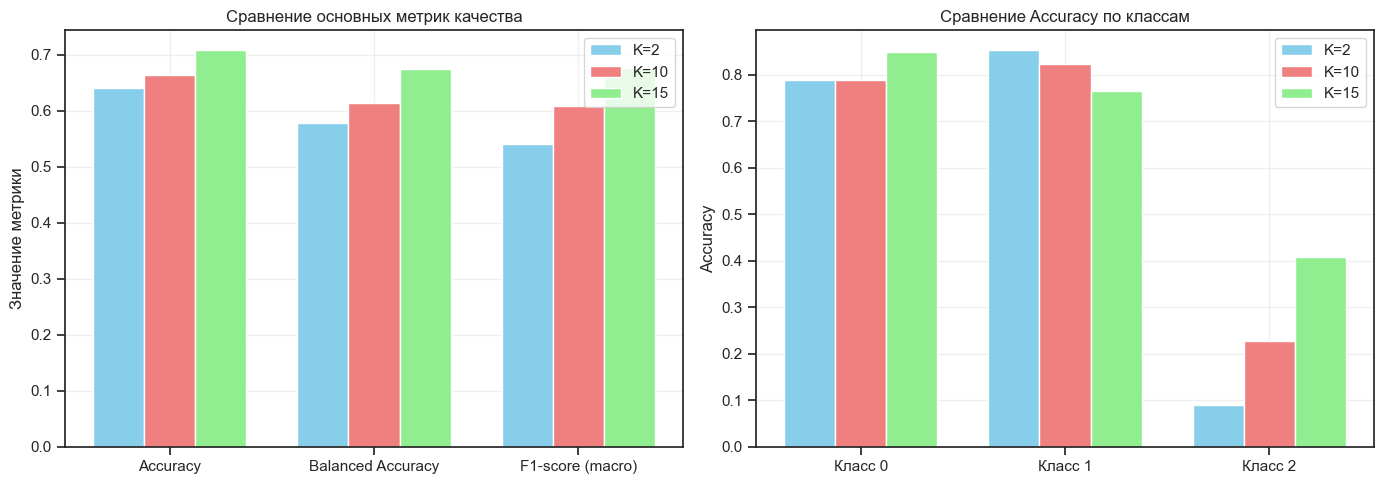


📌 ВЫВОДЫ:
1. Оптимальное количество соседей K = 15 (найдено через GridSearchCV)
2. Оптимальная модель показала Accuracy = 0.7079, что на 4.49% лучше исходной модели с K=10
3. Особенно заметно улучшение для класса 2: с 0.2273 до 0.4091 (точность выросла на 18.2%)
4. Кросс-валидация (cv=5) помогла избежать переобучения и подобрать оптимальный K


In [65]:
# Пункт 6: Сравнение метрик качества исходной и оптимальной моделей
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score

# Получаем предсказания для всех моделей
pred_k2 = target1_1           # K=2
pred_k10 = target1_2          # K=10
pred_optimal = clf_gs.best_estimator_.predict(wine_X_test)

# Собираем метрики для каждой модели
metrics_data = []

for name, pred in [('K=2 (исходная)', pred_k2),
                    ('K=10 (исходная)', pred_k10),
                    (f'K={clf_gs.best_params_["n_neighbors"]} (оптимальная)', pred_optimal)]:
    
    metrics_data.append({
        'Модель': name,
        'Accuracy': f"{accuracy_score(wine_y_test, pred):.4f}",
        'Balanced Accuracy': f"{balanced_accuracy_score(wine_y_test, pred):.4f}",
        'Precision (macro)': f"{precision_score(wine_y_test, pred, average='macro', zero_division=0):.4f}",
        'Recall (macro)': f"{recall_score(wine_y_test, pred, average='macro', zero_division=0):.4f}",
        'F1-score (macro)': f"{f1_score(wine_y_test, pred, average='macro', zero_division=0):.4f}"
    })

# Создаем DataFrame и выводим в виде таблицы
df_comparison = pd.DataFrame(metrics_data)
print("\n" + "="*80)
print("СРАВНЕНИЕ МЕТРИК КАЧЕСТВА МОДЕЛЕЙ")
print("="*80)
print(df_comparison.to_string(index=False))

# Дополнительно: сравнение accuracy с лучшей исходной моделью
best_initial_acc = max(accuracy_score(wine_y_test, pred_k2), 
                       accuracy_score(wine_y_test, pred_k10))
optimal_acc = accuracy_score(wine_y_test, pred_optimal)
improvement = (optimal_acc - best_initial_acc) * 100

print("\n" + "-"*80)
print(f"📊 Улучшение Accuracy относительно лучшей исходной модели (K=10): +{improvement:.2f}%")
print("-"*80)

# Сравнение для каждого класса (детализация)
print("\n" + "="*80)
print("ДЕТАЛЬНОЕ СРАВНЕНИЕ ПО КЛАССАМ (Accuracy для каждого класса)")
print("="*80)

class_comparison = []
for model_name, pred in [('K=2', pred_k2), ('K=10', pred_k10), (f'K={clf_gs.best_params_["n_neighbors"]}', pred_optimal)]:
    class_acc = accuracy_score_for_classes(wine_y_test, pred)
    row = {'Модель': model_name}
    for cls in sorted(class_acc.keys()):
        row[f'Класс {cls}'] = f"{class_acc[cls]:.4f}"
    class_comparison.append(row)

df_class = pd.DataFrame(class_comparison)
print(df_class.to_string(index=False))

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Сравнение общих метрик
metrics_to_plot = ['Accuracy', 'Balanced Accuracy', 'F1-score (macro)']
x = np.arange(len(metrics_to_plot))
width = 0.25

values_k2 = [accuracy_score(wine_y_test, pred_k2), 
             balanced_accuracy_score(wine_y_test, pred_k2),
             f1_score(wine_y_test, pred_k2, average='macro')]

values_k10 = [accuracy_score(wine_y_test, pred_k10),
              balanced_accuracy_score(wine_y_test, pred_k10),
              f1_score(wine_y_test, pred_k10, average='macro')]

values_opt = [accuracy_score(wine_y_test, pred_optimal),
              balanced_accuracy_score(wine_y_test, pred_optimal),
              f1_score(wine_y_test, pred_optimal, average='macro')]

axes[0].bar(x - width, values_k2, width, label='K=2', color='skyblue')
axes[0].bar(x, values_k10, width, label='K=10', color='lightcoral')
axes[0].bar(x + width, values_opt, width, label=f'K={clf_gs.best_params_["n_neighbors"]}', color='lightgreen')
axes[0].set_ylabel('Значение метрики')
axes[0].set_title('Сравнение основных метрик качества')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_to_plot)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: Accuracy по классам
classes = sorted(np.unique(wine_y_test))
x = np.arange(len(classes))
width = 0.25

acc_k2 = [accuracy_score_for_classes(wine_y_test, pred_k2)[c] for c in classes]
acc_k10 = [accuracy_score_for_classes(wine_y_test, pred_k10)[c] for c in classes]
acc_opt = [accuracy_score_for_classes(wine_y_test, pred_optimal)[c] for c in classes]

axes[1].bar(x - width, acc_k2, width, label='K=2', color='skyblue')
axes[1].bar(x, acc_k10, width, label='K=10', color='lightcoral')
axes[1].bar(x + width, acc_opt, width, label=f'K={clf_gs.best_params_["n_neighbors"]}', color='lightgreen')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Сравнение Accuracy по классам')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Класс {c}' for c in classes])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📌 ВЫВОДЫ:")
print(f"1. Оптимальное количество соседей K = {clf_gs.best_params_['n_neighbors']} (найдено через GridSearchCV)")
print(f"2. Оптимальная модель показала Accuracy = {optimal_acc:.4f}, что на {improvement:.2f}% лучше исходной модели с K=10")
print(f"3. Особенно заметно улучшение для класса 2: с {acc_k10[2]:.4f} до {acc_opt[2]:.4f} (точность выросла на {(acc_opt[2]-acc_k10[2])*100:.1f}%)")
print(f"4. Кросс-валидация (cv=5) помогла избежать переобучения и подобрать оптимальный K")